<a href="https://colab.research.google.com/github/HiraNawaz2415/DL-Assignment-1/blob/main/GradientDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment Question DL Implementation of Gradient Descent Algorithm

There are three types of GD:
1. SGD
2. Batch GD
3. Mini Bact GD

## Problem

Predict house price based on:

Size (sqft)

Number of Bedrooms

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [44]:
# -----------------------
# Create Data
# -----------------------
np.random.seed(0)
n = 200
# Real-world type features
size = np.random.randint(500, 3000, n)          # house size in sqft
bedrooms = np.random.randint(1, 6, n)           # number of bedrooms

In [45]:
price = (
    100000 +                 # base price (intercept)
    3000 * size +            # price per sqft
    50000 * bedrooms +       # bedroom effect
    np.random.normal(0, 20000, n)  # market noise
).astype(int)

In [46]:
# Create tabular dataset
data = pd.DataFrame({
    "Size_sqft": size,
    "Bedrooms": bedrooms,
    "Price": price
})

In [47]:
data.head()

,Size_sqft,Bedrooms,Price
0,2153,2,6635876
1,1335,3,4270623
2,1263,4,4118889
3,2231,2,6851600
4,1533,5,4957525


In [48]:
# -----------------------
# Initialize parameters
# -----------------------
w1 = w2=1
b = 0
lr = 0.01




In [49]:
def mean_squared_error(y_true, y_pred):
    n = len(y_true)
    mse = np.sum((y_true - y_pred) ** 2) / n
    return mse

In [50]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [51]:
# -----------------------
# Batch Gradient Descent
# -----------------------
def GD_batch(Size_sqft, Bedrooms, Y_actual, w1, w2, b, lr, epochs):
    n = len(Size_sqft)
    for epoch in range(epochs):
        # Vectorized weighted sum (predictions)
        y_pred = w1*Size_sqft + w2*Bedrooms + b
        # Compute loss
        loss = mean_squared_error(Y_actual, y_pred)
        losses.append(loss)
        # Vectorized gradient calculation
        dw1 = (2/n) * np.sum(Size_sqft * (y_pred - Y_actual))
        dw2 = (2/n) * np.sum(Bedrooms * (y_pred - Y_actual))
        db  = (2/n) * np.sum(y_pred - Y_actual)
        # Update weights
        w1 = w1 - lr * dw1
        w2 = w2 - lr * dw2
        b  = b  - lr * db
        # Print progress
        if epoch % 10 == 0 or epoch == epochs-1:  # print every 10 epochs
            print(f"Epoch:{epoch}, w1:{w1:.2f}, w2:{w2:.2f}, b:{b:.2f}, Loss:{loss:.2f}")

    return w1, w2, b


In [52]:
# -----------------------
# Stochastic Gradient Descent with Shuffling
# -----------------------
def GD_SGD(Size_sqft, Bedrooms, Y_actual, w1, w2, b, lr, epochs):
    n = len(Size_sqft)
    for epoch in range(epochs):
        # Shuffle data at the start of each epoch
        indices = np.random.permutation(n)
        Size_sqft = Size_sqft[indices]
        Bedrooms  = Bedrooms[indices]
        Y_actual  = Y_actual[indices]
        for i in range(n):
            x1 = Size_sqft[i]
            x2 = Bedrooms[i]
            y  = Y_actual[i]
            # Prediction
            y_pred = w1*x1 + w2*x2 + b
            # Error
            error  = y_pred - y
            # Gradients
            dw1 = 2 * x1 * error
            dw2 = 2 * x2 * error
            db  = 2 * error
            # Update weights immediately
            w1 -= lr * dw1
            w2 -= lr * dw2
            b  -= lr * db
        # Compute average loss for the epoch
        avg_loss = np.mean((w1*Size_sqft + w2*Bedrooms + b - Y_actual)**2)
        losses.append(avg_loss)
        if epoch % 10 == 0 or epoch == epochs-1:
            print(f"Epoch:{epoch}, w1:{w1:.2f}, w2:{w2:.2f}, b:{b:.2f}, Loss:{avg_loss:.4f}")
    return w1, w2, b



In [53]:
# -----------------------
# Mini-Batch Gradient Descent
# -----------------------
def GD_mini_batch(Size_sqft, Bedrooms, Y_actual, w1, w2, b, lr, epochs, batch_size):
    n = len(Size_sqft)
    for epoch in range(epochs):
        # Shuffle data at start of each epoch
        indices = np.random.permutation(n)
        Size_sqft = Size_sqft[indices]
        Bedrooms  = Bedrooms[indices]
        Y_actual  = Y_actual[indices]
        # Loop through mini-batches
        for i in range(0, n, batch_size):
            # Create mini-batch
            X1_batch = Size_sqft[i:i+batch_size]
            X2_batch = Bedrooms[i:i+batch_size]
            Y_batch  = Y_actual[i:i+batch_size]
            m = len(X1_batch)
            # Prediction
            y_pred = w1*X1_batch + w2*X2_batch + b
            # Error
            error = y_pred - Y_batch
            # Gradients
            dw1 = (2/m) * np.sum(X1_batch * error)
            dw2 = (2/m) * np.sum(X2_batch * error)
            db  = (2/m) * np.sum(error)
            # Update weights
            w1 -= lr * dw1
            w2 -= lr * dw2
            b  -= lr * db
        # Compute loss for the epoch
        loss = np.mean((w1*Size_sqft + w2*Bedrooms + b - Y_actual)**2)
        losses.append(loss)
        if epoch % 10 == 0 or epoch == epochs-1:
            print(f"Epoch:{epoch}, w1:{w1:.2f}, w2:{w2:.2f}, b:{b:.2f}, Loss:{loss:.4f}")
    return w1, w2, b

In [54]:
# Scale features
X1 = (data['Size_sqft'] - data['Size_sqft'].mean()) / data['Size_sqft'].std()
X2 = (data['Bedrooms'] - data['Bedrooms'].mean()) / data['Bedrooms'].std()
Y = data['Price']

In [55]:
# convert to numpy arrays
X1 = X1.values
X2 = X2.values
Y  = Y.values

In [56]:
epochs = int(input("Enter no of epochs: "))   # take epochs as input

Enter no of epochs: 10


In [62]:
# User choice for Gradient Descent type
print("Choose Gradient Descent method:")
print("1: Stochastic Gradient Descent (SGD)")
print("2: Batch Gradient Descent")
print("3: Mini-Batch Gradient Descent")
choice = input("Enter choice (1/2/3): ")
if choice == "1":
    losses = []
    w1, w2, b = GD_SGD(X1, X2, Y, w1, w2, b, lr, epochs)
    print("SGD executed.")
elif choice == "2":
    losses = []
    w1, w2, b = GD_batch(X1, X2, Y, w1, w2, b, lr, epochs)
    print("Batch GD executed.")
elif choice == "3":
    # For mini-batch, you may want to ask batch size too
    batch_size = int(input("Enter batch size for Mini-Batch GD: "))
    losses = []
    w1, w2, b = GD_mini_batch(X1, X2, Y, w1, w2, b, lr, epochs, batch_size)
    print("Mini-Batch GD executed.")
else:
    print("Invalid choice! Please enter 1, 2, or 3.")


Choose Gradient Descent method:
1: Stochastic Gradient Descent (SGD)
2: Batch Gradient Descent
3: Mini-Batch Gradient Descent
Enter choice (1/2/3): 3
Enter batch size for Mini-Batch GD: 4
Epoch:0, w1:2145752.37, w2:73243.71, b:5740442.73, Loss:386410045.7909
Epoch:9, w1:2145998.13, w2:72880.05, b:5740560.76, Loss:386284250.3260
Mini-Batch GD executed.


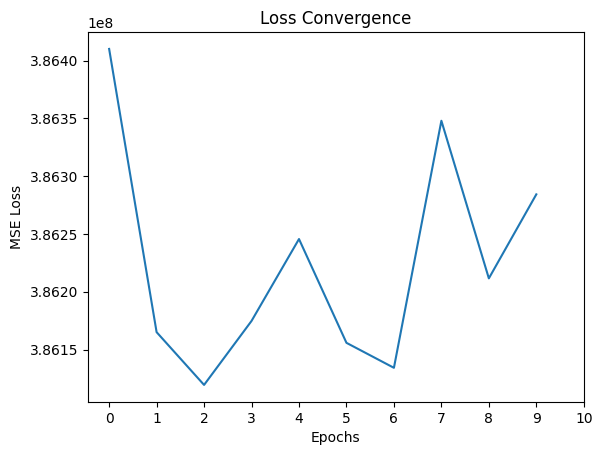

In [63]:
plt.plot(range(epochs), losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Convergence")
# Force integer ticks
plt.xticks(range(0, epochs+1, 1))  # step=1 shows every epoch as tick
plt.show()